# Figure3

In [1]:
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
import pandas as pd 
import matplotlib.colors as mcolors
from matplotlib import rcParams, rcParamsDefault
from matplotlib.lines import Line2D

EIDS_TO_CELLTYPES = {
    'E116':'GM12878',
    'E118':'HepG2',
    'E003':'H1'
}


In [2]:


rcParams.update(rcParamsDefault)
rcParams['pdf.fonttype'] = 42
sns.set(context = 'paper' , style='ticks' , 
    rc = {
        'figure.autolayout' : True,
        'font.sans-serif': ['Arial', 'Helvetica'],  # Specify Arial or Helvetica
        'axes.titlesize' : 8 ,
        'axes.titleweight' :'bold',
        'axes.titlesize': 10,  # Title font size
        
        'figure.titleweight' : 'bold' ,
        'figure.titlesize' : 8 ,
        
        'axes.labelsize' : 8 ,
        'axes.labelpad' : 2 ,
        # 'axes.labelweight' : 'bold' , 
        'axes.spines.top' : False,
        'axes.spines.right' : False,
        
        'xtick.labelsize' : 7 ,
        'ytick.labelsize' : 7 ,
        
        'legend.fontsize' : 8 ,
        'figure.figsize' : (8/2.54, 8/2.54) , 
        'figure.dpi': 300,      
        'figure.facecolor': 'w',
        'figure.edgecolor': 'k',   
        
        'xtick.direction' : 'out' ,
        'ytick.direction' : 'out' ,
        
        'xtick.major.size' : 2 ,
        'ytick.major.size' : 2 ,
        'xtick.minor.size': 2,  # X-axis minor tick length
        'ytick.minor.size': 2,  # Y-axis minor tick length

        'xtick.major.pad' : 2,
        'ytick.major.pad' : 2,
        
        'lines.linewidth' : 0.75  , 
        'axes.linewidth': 0.5,  # Axis line width
        'savefig.dpi': 300,  # Save resolution 
        'savefig.bbox': 'tight',  # Tight bounding box       
        }
    )

sns.set_palette("colorblind")


## Define heatmap function

## Feature importance (Fig3B)

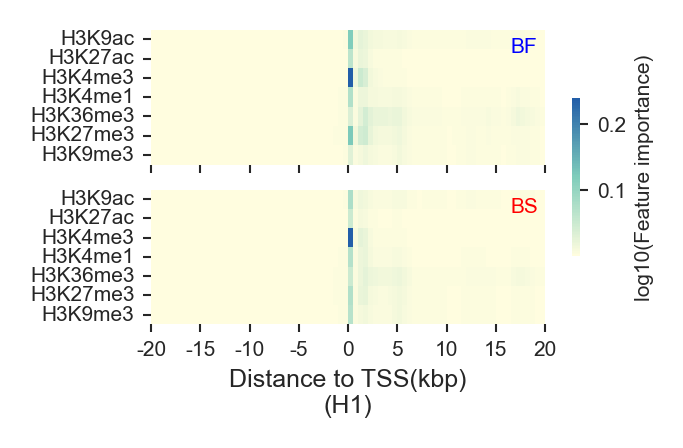

In [59]:
eid = 'E003'
COLORS = ['#FFFDDF', "#7FCDBB", "#225EA8"]
MARKS = ["H3K4me1","H3K4me3","H3K9me3","H3K27me3","H3K36me3","H3K27ac","H3K9ac"]
yticks = [ 'H3K9ac', 'H3K27ac','H3K4me3','H3K4me1','H3K36me3','H3K27me3','H3K9me3']
idxes = [MARKS.index(mark) for mark in yticks]

with open(f'extra/datasets/benchmark/Promoterformer/results/{eid}_bf_deeplift_attributions.npy','rb') as f:
   attributions1 =  np.load(f)
   attributions1 = attributions1[idxes]

with open(f'extra/datasets/benchmark/Promoterformer/results/{eid}_bs_deeplift_attributions.npy','rb') as f:
   attributions2 =  np.load(f)
   attributions2 = attributions2[idxes]

fig, ax = plt.subplots(2, 1, constrained_layout=True, figsize=(5.5/2.54, 3.5/2.54))

xticks = [i for i in range(0, 81, 10)]
sns.heatmap((attributions1), cmap=mcolors.LinearSegmentedColormap.from_list("colormap", COLORS, N=100),
            ax=ax[0], cbar=False)
ax[0].tick_params(axis='both', labelsize=5, width=0.5)

sns.heatmap((attributions2), cmap=mcolors.LinearSegmentedColormap.from_list("colormap", COLORS, N=100),
            ax=ax[1],cbar=False)
ax[1].tick_params(axis='both', labelsize=5, width=0.5)

xticklabels = [int((i - 40) / 2) for i in range(0, 81, 10)]
ax[0].set_xticks(np.arange(0, 81, 10))
ax[1].set_xticks(np.arange(0, 81, 10), labels=xticklabels)

ax[0].set_yticks(np.arange(len(yticks))+0.5)
ax[0].set_yticklabels(yticks, rotation=360, fontsize=5)
ax[1].set_yticks(np.arange(len(yticks))+0.5)
ax[1].set_yticklabels(yticks, rotation=360, fontsize=5)
ax[1].set_xlabel(f"Distance to TSS(kbp)\n({EIDS_TO_CELLTYPES[eid]})", fontsize=6,ha='center')


ax[0].text(73,1.2,"BF",fontdict={"size":5,"color":"blue"})
ax[1].text(73,1.2,"BS",fontdict={"size":5,"color":"red"})

cbar = fig.colorbar(ax[1].collections[0], ax=ax, orientation='vertical', fraction=0.02, pad=0.04)
cbar.outline.set_visible(False)
# # 更改 colorbar 的字体大小
cbar.ax.tick_params(width=0.5, labelsize=5)
cbar.set_label('log10(Feature importance)',fontsize=5)

plt.savefig(f'extra/datasets/benchmark/Promoterformer/figures/Figure3B_{EIDS_TO_CELLTYPES[eid]}.eps', format='eps', bbox_inches='tight')

plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


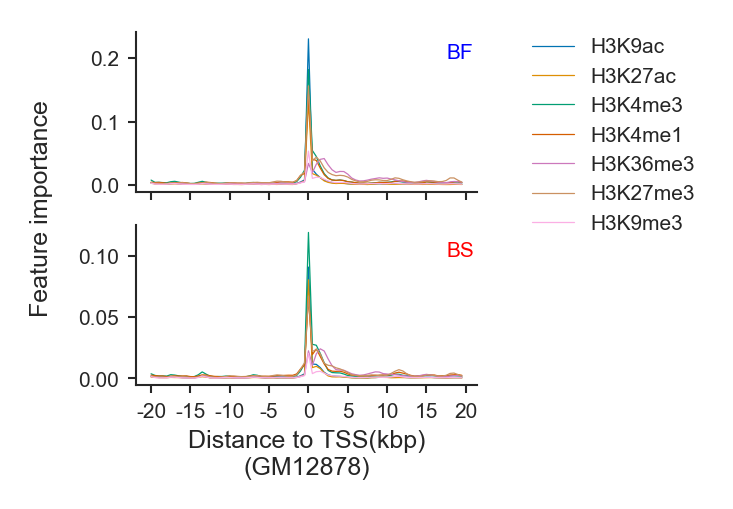

In [60]:
eid = 'E116'
COLORS = ['#FFFDDF', "#7FCDBB", "#225EA8"]
MARKS = ["H3K4me1","H3K4me3","H3K9me3","H3K27me3","H3K36me3","H3K27ac","H3K9ac"]
yticks = [ 'H3K9ac', 'H3K27ac','H3K4me3','H3K4me1','H3K36me3','H3K27me3','H3K9me3']
idxes = [MARKS.index(mark) for mark in yticks]

with open(f'extra/datasets/benchmark/Promoterformer/results/{eid}_bf_deeplift_attributions.npy','rb') as f:
   attributions1 =  np.load(f)
   attributions1 = attributions1[idxes]

with open(f'extra/datasets/benchmark/Promoterformer/results/{eid}_bs_deeplift_attributions.npy','rb') as f:
   attributions2 =  np.load(f)
   attributions2 = attributions2[idxes]

fig, ax = plt.subplots(2, 1, constrained_layout=True, figsize=(4/2.54, 4/2.54))

xticks = [i for i in range(0, 81, 10)]
for _idx, ytick in enumerate(yticks):
   sns.lineplot(attributions1[_idx],label=ytick,ax=ax[0],linewidth=0.3)

ax[0].tick_params(axis='both', labelsize=5, width=0.5)

for _idx, ytick in enumerate(yticks):
   sns.lineplot(attributions2[_idx],label=ytick,ax=ax[1],linewidth=0.3)

ax[0].legend().remove()
ax[1].legend().remove()
ax[1].tick_params(axis='both', labelsize=5, width=0.5)

xticklabels = [int((i - 40) / 2) for i in range(0, 81, 10)]
ax[0].set_xticks(np.arange(0, 81, 10),labels='')
ax[1].set_xticks(np.arange(0, 81, 10), labels=xticklabels)

ax[1].set_xlabel(f"Distance to TSS(kbp)\n({EIDS_TO_CELLTYPES[eid]})", fontsize=6,ha='center')

handles, labels = ax[0].get_legend_handles_labels()
# Add a legend at the upper right of the 3rd subplot (1st row, 3rd column)
fig.supylabel(f"Feature importance", fontsize=6,y=0.6)
fig.legend(handles, labels, loc='upper left', bbox_to_anchor=(1.05, 1.0), fontsize=5,edgecolor='none')

ax[0].text(75,0.2,"BF",fontdict={"size":5,"color":"blue"})
ax[1].text(75,0.1,"BS",fontdict={"size":5,"color":"red"})


plt.savefig(f'extra/datasets/benchmark/Promoterformer/figures/Figure3B_{EIDS_TO_CELLTYPES[eid]}.eps', format='eps', bbox_inches='tight')

plt.show()

### BS BF locations importance

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


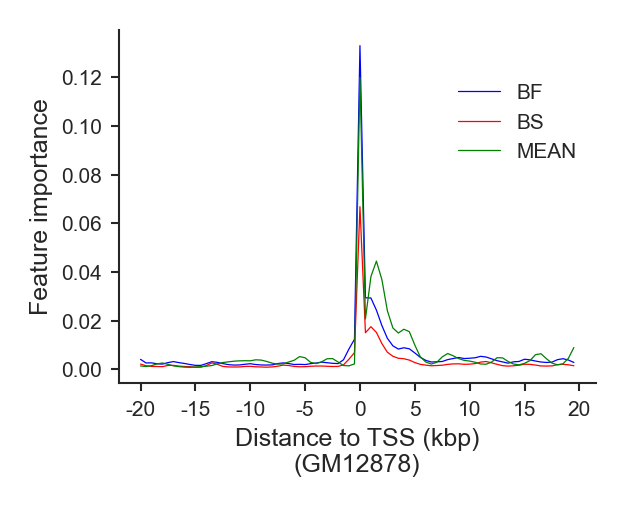

In [4]:
eid = 'E116'
with open(f'extra/datasets/benchmark/Promoterformer/results/{eid}_bf_deeplift_distribution.npy','rb') as f:
   distribution1 =  np.load(f)

with open(f'extra/datasets/benchmark/Promoterformer/results/{eid}_bs_deeplift_distribution.npy','rb') as f:
   distribution2 =  np.load(f)

with open(f'extra/datasets/benchmark/Promoterformer/results/{eid}_mean_deeplift_distribution.npy','rb') as f:
   distribution3 =  np.load(f)

fig, ax =plt.subplots(1,1,constrained_layout=True, figsize=(5/2.54, 4/2.54))

sns.lineplot(distribution1,color='blue', label = 'BF',linewidth=0.3)
sns.lineplot(distribution2,color='red', label = 'BS',linewidth=0.3)
sns.lineplot(distribution3,color='green', label = 'MEAN',linewidth=0.3)

# g1 = sns.lineplot(distribution1, color='red', label = 'BF')
# g2 = sns.lineplot(distribution2, color='blue', label = 'BS')
# Adjust layout to ensure everything fits
ax.legend( bbox_to_anchor=(1, 0.9),fontsize=5,edgecolor='none')
ax.set_xticks([i for i in range(0,81,10)])

xticklabels = [int((i-40)/2) for i in range(0,81,10)]
ax.set_xticklabels(xticklabels)
ax.set_xticklabels(xticklabels)
ax.tick_params(axis='both', labelsize=5,width=0.5)

ax.set_xlabel(f"Distance to TSS (kbp)\n({EIDS_TO_CELLTYPES[eid]})",fontsize=6,ha='center')
ax.set_ylabel(f"Feature importance",fontsize=6,ha='center')

plt.savefig(f'extra/datasets/benchmark/Promoterformer/figures/Figure3A_{EIDS_TO_CELLTYPES[eid]}.eps', format='eps', bbox_inches='tight')
plt.show()

### Correlation between HMs

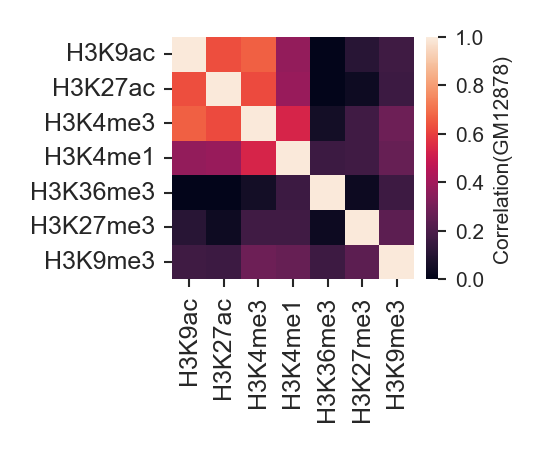

In [62]:
eid = 'E116'
# correlation
#correlation = np.loadtxt('extra/datasets/benchmark/Promoterformer/results/{eid}_hm_correlation.csv',delimiter=",")
correlation = np.loadtxt(f'extra/datasets/benchmark/Promoterformer/results/{eid}_hm_correlation.csv',delimiter=",")
# 选择第 0 个样本的行间相关性矩阵
MARKS =  [ 'H3K9ac', 'H3K27ac','H3K4me3','H3K4me1','H3K36me3','H3K27me3','H3K9me3']
fig, ax = plt.subplots(1, 1, constrained_layout=True, figsize=(4.3/2.54, 4.3/2.54))
ax = sns.heatmap(correlation,cbar_kws={"shrink": 0.6, "fraction": 0.05},vmin=0, vmax=1)
ax.set_xticklabels(MARKS,rotation=90)
ax.set_yticklabels(MARKS,rotation=360)
ax.set_aspect('equal')
ax.tick_params(axis='both', labelsize=6,width=0.5)  # 修改刻度标签字体大小
cbar = ax.collections[0].colorbar

# 调整colorbar的刻度粗细
cbar.ax.tick_params(width=0.5,labelsize=5)  # 设置colorbar刻度的粗细
cbar.set_label(f'Correlation({EIDS_TO_CELLTYPES[eid]})',fontsize=5)
plt.savefig(f'extra/datasets/benchmark/Promoterformer/figures/Figure3C_{EIDS_TO_CELLTYPES[eid]}.eps', format='eps', bbox_inches='tight')
plt.show()


### BS pred score marks strength （All BS）

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


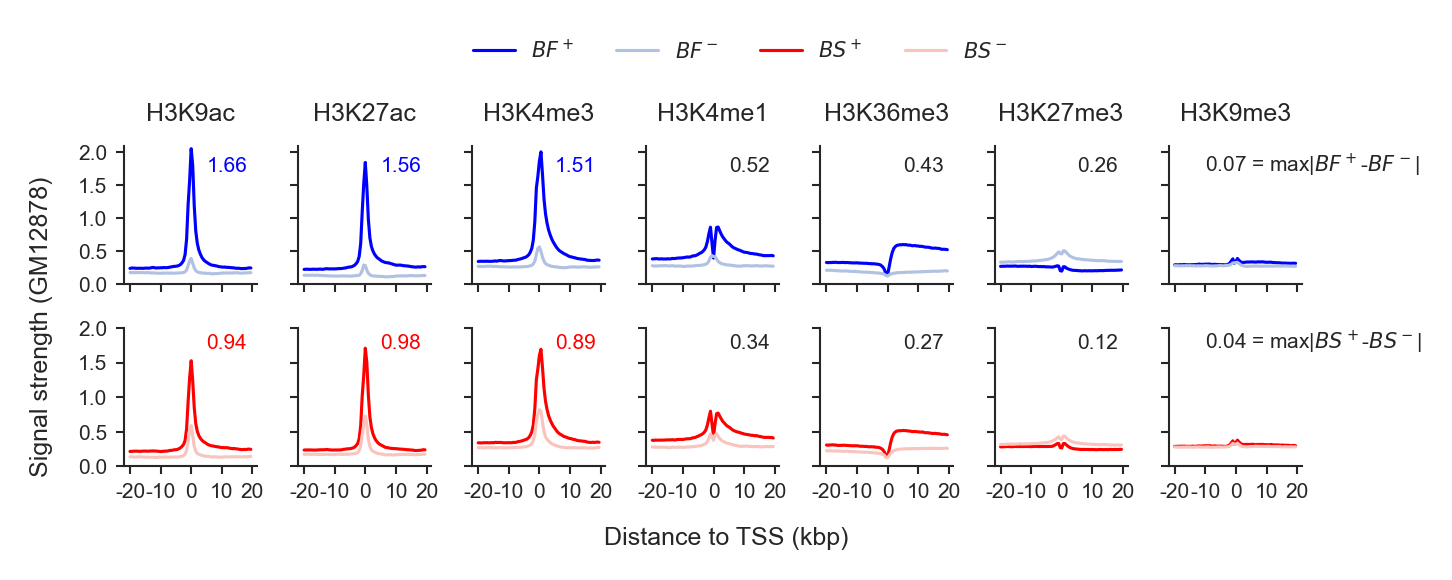

In [6]:
eid = 'E116'
high_marks = np.load(f"extra/datasets/benchmark/Promoterformer/results/{eid}_bf_highmarks.npy")
low_marks = np.load(f"extra/datasets/benchmark/Promoterformer/results/{eid}_bf_lowmarks.npy")
MARKS = ['H3K4me1', 'H3K4me3', 'H3K9me3', 'H3K27me3', 'H3K36me3', 'H3K27ac', 'H3K9ac']
yticks = [ 'H3K9ac', 'H3K27ac','H3K4me3','H3K4me1','H3K36me3','H3K27me3','H3K9me3']

fig, ax = plt.subplots(2, 7, constrained_layout=True, figsize=(12/2.54, 4/2.54))

# Loop through the plots and plot the data without labels for legends
for idx, mark in enumerate(yticks):
    _idx = MARKS.index(mark)
    # Plot the data without 'label' argument to avoid legends in subplots
    sns.lineplot(high_marks[_idx], color='blue',  ax=ax[0, idx % 7])
    sns.lineplot(low_marks[_idx], color=(177/255,193/255,225/255),  ax=ax[0, idx % 7])
    # ax[0, idx % 7].text(0,1.7,f"max|$BS^+-BF^-$|={round(max(abs(high_marks[_idx]-low_marks[_idx])),2)}",fontdict={"size":5}) 
    if idx < 3:
        ax[0, idx % 7].text(50,1.7,round(max(abs(high_marks[_idx]-low_marks[_idx])),2),fontdict={"size":5}, color='blue')
    elif idx ==6:
        ax[0, idx % 7].text(20,1.7,f"{round(max(abs(high_marks[_idx]-low_marks[_idx])),2)} = max|$BF^+$-$BF^-$|",fontdict={"size":5})
    else:
        ax[0, idx % 7].text(50,1.7,round(max(abs(high_marks[_idx]-low_marks[_idx])),2),fontdict={"size":5})
    # Set the y-axis ticks
    ax[0, idx % 7].set_yticks([i * 0.1 for i in range(0, 21, 5)])
    ax[0, idx % 7].set_xticks([i for i in range(0, 81, 20)],labels=[int((i-40)/2) for i in range(0, 81, 20)])
    if idx == 0:
        ax[0, idx % 7].tick_params(axis='both', labelsize=5,width=0.5,labelbottom=False)
    else:
        ax[0, idx % 7].tick_params(axis='both', labelsize=5,width=0.5,labelbottom=False,labelleft=False)
    # Set the title for each subplot
    ax[0, idx % 7].set_title(mark, fontsize=6,fontweight='regular')
    ax[0, idx % 7].set_ylim(ymax=2.1)
    # Set the xlabel for each subplot

lines = ax[0,6].get_lines()

handles1 = [lines[0], lines[1]]
labels1 = ["$BF^+$", "$BF^-$"]
# ax[0,6].legend(handles,labels,loc='upper right', bbox_to_anchor=(1.7, 0.6),fontsize=4,handlelength=1.5,edgecolor='none') 

high_marks = np.load(f"extra/datasets/benchmark/Promoterformer/results/{eid}_bs_highmarks.npy")
low_marks = np.load(f"extra/datasets/benchmark/Promoterformer/results/{eid}_bs_lowmarks.npy")
MARKS = ['H3K4me1', 'H3K4me3', 'H3K9me3', 'H3K27me3', 'H3K36me3', 'H3K27ac', 'H3K9ac']
yticks = [ 'H3K27ac', 'H3K9ac','H3K4me3','H3K4me1','H3K36me3','H3K27me3','H3K9me3']

for idx, mark in enumerate(yticks):
    _idx = MARKS.index(mark)
    # Plot the data without 'label' argument to avoid legends in subplots
    sns.lineplot(high_marks[_idx], color='red',  ax=ax[1, idx % 7])
    sns.lineplot(low_marks[_idx], color=(248/255,196/255,189/255),  ax=ax[1, idx % 7])
    if idx < 3:
        ax[1, idx % 7].text(50,1.7,round(max(abs(high_marks[_idx]-low_marks[_idx])),2),fontdict={"size":5}, color='red')
    elif idx ==6:
        ax[1, idx % 7].text(20,1.7,f"{round(max(abs(high_marks[_idx]-low_marks[_idx])),2)} = max|$BS^+$-$BS^-$|",fontdict={"size":5})
    else:
        ax[1, idx % 7].text(50,1.7,round(max(abs(high_marks[_idx]-low_marks[_idx])),2),fontdict={"size":5})
    # Set the y-axis ticks
    ax[1, idx % 7].set_yticks([i * 0.1 for i in range(0, 21, 5)])
    ax[1, idx % 7].set_xticks([i for i in range(0, 81, 20)],labels=[int((i-40)/2) for i in range(0, 81, 20)])
    if idx == 0:
        ax[1, idx % 7].tick_params(axis='both', labelsize=5,width=0.5,)
    else:
        ax[1, idx % 7].tick_params(axis='both', labelsize=5,width=0.5,labelleft=False)
    ax[1, idx % 7].set_ylim(ymax=2.0)
    # Set the xlabel for each subplot

lines = ax[1,6].get_lines()

handles2 = [lines[0], lines[1]]
labels2 = ["$BS^+$", "$BS^-$"]
# ax[1,6].legend(handles,labels,loc='upper right', bbox_to_anchor=(1.7, 0.6),fontsize=4,handlelength=1.5,edgecolor='none') 
# ax[1,6].legend(loc='upper right', bbox_to_anchor=(1.7, 0.6))
# Create a single shared legend
# Handles are explicitly created using the line objects from the first plot
# handles, labels = ax[0, 0].get_lines(), ['$BS^+$', '$BS^\_$']

# Add a legend at the upper right of the 3rd subplot (1st row, 3rd column)
# fig.legend(handles, labels, loc='upper left', bbox_to_anchor=(1.05, 1.0))
fig.legend(handles1+handles2, labels1+labels2, loc='upper center', bbox_to_anchor=(0.51, 1.15) , title_fontsize=6,fontsize=5,ncol=4,edgecolor='none')

fig.supxlabel("Distance to TSS (kbp)",fontsize=6)
fig.supylabel(f"Signal strength ({EIDS_TO_CELLTYPES[eid]})",fontsize=6)
fig.align_ylabels()
# Adjust layout to ensure everything fits



plt.savefig('extra/datasets/benchmark/Promoterformer/figures/Figure3D.eps', format='eps', bbox_inches='tight')

plt.show()


# One-feature ablation

In [67]:
data = pd.read_csv('extra/datasets/benchmark/Promoterformer/results/one_feature_indicators.csv')
data

,eid,keep_mark,fold,auc,target
0,E116,H3K4me1,0,77.562077,bs_label
1,E116,H3K4me1,0,91.267089,bf_label
2,E116,H3K4me1,1,77.331183,bs_label
3,E116,H3K4me1,1,92.768745,bf_label
4,E116,H3K4me1,2,79.249251,bs_label
...,...,...,...,...,...
163,E003,H3K9ac,1,92.243379,bf_label
164,E003,H3K9ac,2,73.775451,bs_label
165,E003,H3K9ac,2,93.085816,bf_label
166,E003,H3K9ac,3,71.110264,bs_label


## BF one-feature ablation

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_56196/2141555157.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


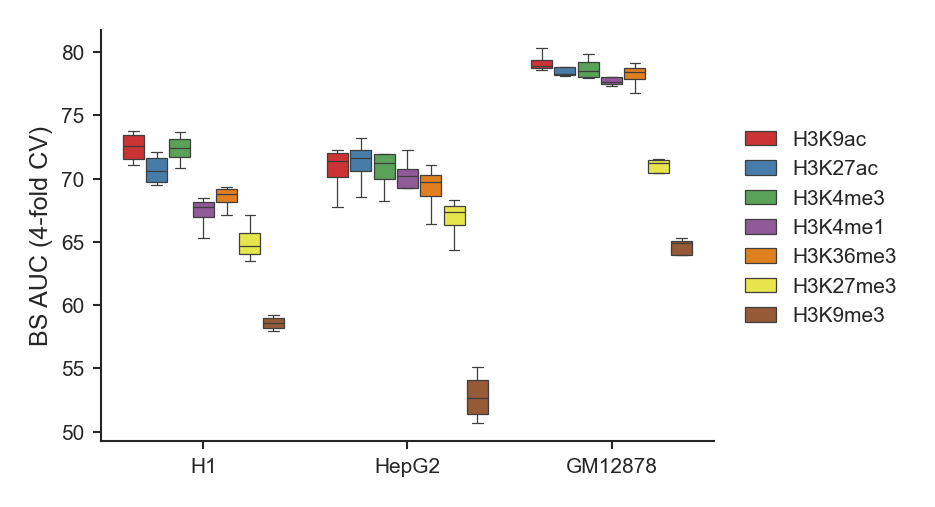

In [20]:
# 设置为 colorblind 调色板
# sns.set_palette("colorblind")
# sns.set_context("paper") 
fig, ax = plt.subplots(1,1, constrained_layout=True, figsize=(6/2.54, 4/2.54))

df = data[data['target'] == 'bs_label']
# fig=plt.figure(figsize=(3.6,3.6) , dpi= 300, facecolor='w', edgecolor='k')
# fig.tight_layout(pad = 1)
hue_order = pd.Index(["H3K9ac","H3K27ac","H3K4me3","H3K4me1","H3K36me3","H3K27me3","H3K9me3"],name='marks')
order = pd.Index(["E003","E118","E116"],name='marks')
ax = sns.boxplot(data=df,y='auc',x='eid',hue='keep_mark',
                 gap=0.1,width=0.8,fliersize=0,order=order,hue_order=hue_order,linewidth=0.3,
                 palette="Set1")
ax.tick_params(axis='both', labelsize=5,width=0.5)
plt.ylabel(f'BS AUC (4-fold CV)',fontsize=6)
# ax.set_ylim(top=4)
ax.set_xlabel('')
ax.legend().remove()
ax.set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
fig.legend(loc='upper left', bbox_to_anchor=(1, 0.8),fontsize=5,handlelength=1.5,edgecolor='none')  
plt.savefig('extra/datasets/benchmark/Promoterformer/figures/Figure3E.eps', format='eps', bbox_inches='tight')
plt.show()

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_45221/362445307.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_45221/362445307.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_45221/362445307.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[2].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


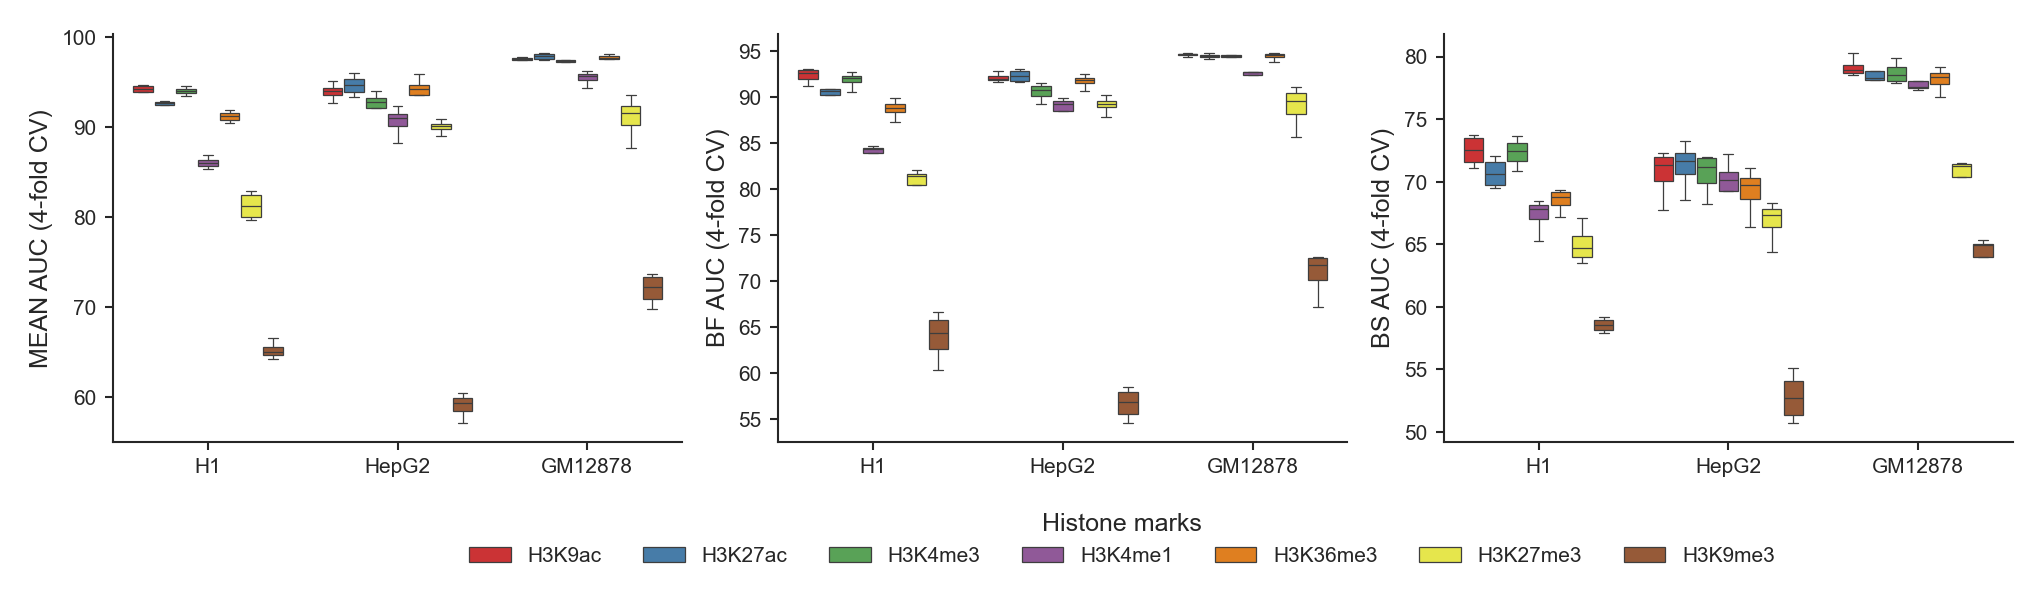

In [78]:
fig, ax = plt.subplots(1,3,constrained_layout=True,figsize=(17/2.54, 4/2.54))

## MEAN
data = pd.read_csv('extra/datasets/benchmark/Promoterformer/results/one_feature_indicators_mean.csv')
df = data[data['target'] == 'mean_label']
# fig=plt.figure(figsize=(3.6,3.6) , dpi= 300, facecolor='w', edgecolor='k')
# fig.tight_layout(pad = 1)
hue_order = pd.Index(["H3K9ac","H3K27ac","H3K4me3","H3K4me1","H3K36me3","H3K27me3","H3K9me3"],name='marks')
order = pd.Index(["E003","E118","E116"],name='marks')
sns.boxplot(data=df,y='auc',x='eid',hue='keep_mark',
                 gap=0.1,width=0.8,fliersize=0,order=order,hue_order=hue_order,linewidth=0.3,
                 palette="Set1",ax=ax[0])
ax[0].tick_params(axis='both', labelsize=5,width=0.5)
ax[0].set_ylabel(f'MEAN AUC (4-fold CV)',fontsize=6)
# ax.set_ylim(top=4)
ax[0].set_xlabel('')
ax[0].legend().remove()
ax[0].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])

## BS & BF
data = pd.read_csv('extra/datasets/benchmark/Promoterformer/results/one_feature_indicators.csv')

df = data[data['target'] == 'bf_label']
# fig=plt.figure(figsize=(3.6,3.6) , dpi= 300, facecolor='w', edgecolor='k')
# fig.tight_layout(pad = 1)

hue_order = pd.Index(["H3K9ac","H3K27ac","H3K4me3","H3K4me1","H3K36me3","H3K27me3","H3K9me3"],name='marks')
order = pd.Index(["E003","E118","E116"],name='marks')
sns.boxplot(data=df,y='auc',x='eid',hue='keep_mark',
                 gap=0.1,width=0.8,fliersize=0,order=order,hue_order=hue_order,linewidth=0.3,
                 palette="Set1",ax=ax[1])
ax[1].tick_params(axis='both', labelsize=5,width=0.5)
ax[1].set_ylabel(f'BF AUC (4-fold CV)',fontsize=6)
# ax.set_ylim(top=4)
ax[1].set_xlabel('')
ax[1].legend().remove()
ax[1].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
# plt.savefig('extra/datasets/benchmark/Promoterformer/figures/Figure3F.eps', format='eps', bbox_inches='tight')
# plt.show()


df = data[data['target'] == 'bs_label']
# fig=plt.figure(figsize=(3.6,3.6) , dpi= 300, facecolor='w', edgecolor='k')
# fig.tight_layout(pad = 1)
hue_order = pd.Index(["H3K9ac","H3K27ac","H3K4me3","H3K4me1","H3K36me3","H3K27me3","H3K9me3"],name='marks')
order = pd.Index(["E003","E118","E116"],name='marks')
sns.boxplot(data=df,y='auc',x='eid',hue='keep_mark',
                 gap=0.1,width=0.8,fliersize=0,order=order,hue_order=hue_order,linewidth=0.3,
                 palette="Set1",ax=ax[2])

ax[2].tick_params(axis='both', labelsize=5,width=0.5)
ax[2].set_ylabel(f'BS AUC (4-fold CV)',fontsize=6)
# ax.set_ylim(top=4)
ax[2].set_xlabel('')
ax[2].legend().remove()
ax[2].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])

handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.55, -0.01) , title_fontsize=6,title='Histone marks', fontsize=5,ncol=7,edgecolor='none')
plt.savefig('extra/datasets/benchmark/Promoterformer/figures/Figure3EFG.eps', format='eps', bbox_inches='tight')

plt.show()

## One-feature drop ablation Analysis

In [ ]:
ablations = pd.read_csv('extra/datasets/benchmark/Promoterformer/results/ablation.csv',sep='\t')
ablation_mean =  pd.read_csv('extra/datasets/benchmark/Promoterformer/results/ablation_mean.csv',sep='\t')
ablation_mean

,auc,remove_mark,fold,eid
0,96.869815,remove_H3K4me1,0,E003
1,96.839021,remove_H3K4me3,0,E003
2,96.740669,remove_H3K9me3,0,E003
3,96.700280,remove_H3K27me3,0,E003
4,95.893554,remove_H3K36me3,0,E003
...,...,...,...,...
91,98.993725,remove_H3K27me3,3,E116
92,98.690890,remove_H3K36me3,3,E116
93,98.989957,remove_H3K27ac,3,E116
94,98.947896,remove_H3K9ac,3,E116


### Ablations

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_6745/25678038.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_6745/25678038.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_6745/25678038.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[2].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


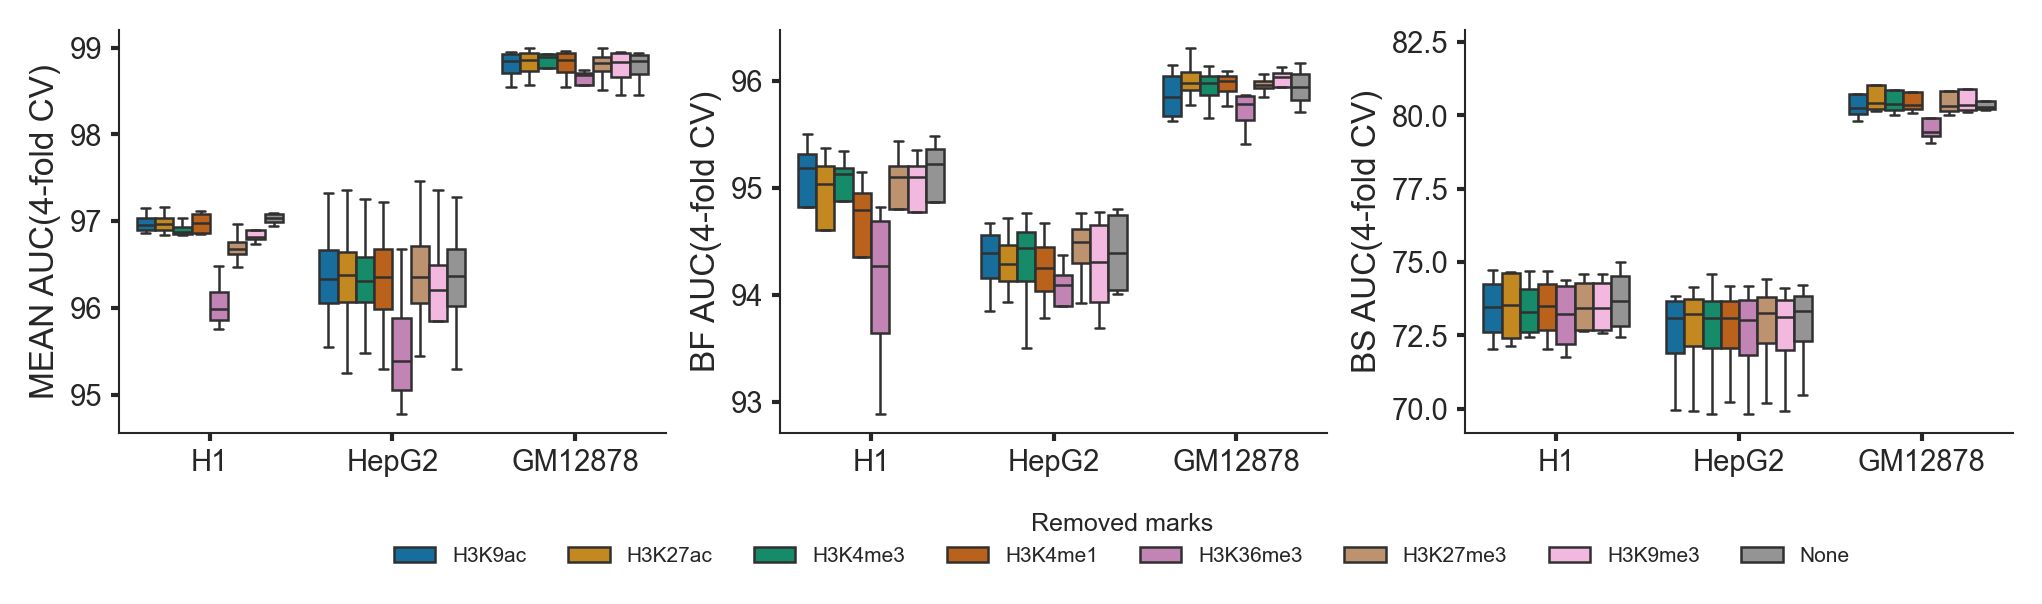

In [ ]:
fig, ax = plt.subplots(1,3,constrained_layout=True,figsize=(17/2.54, 4/2.54))
order = pd.Index(["E003","E118","E116"],name='marks')
hue_order = pd.Index(["remove_H3K9ac","remove_H3K27ac","remove_H3K4me3","remove_H3K4me1","remove_H3K36me3","remove_H3K27me3","remove_H3K9me3","all_marks"],name='marks')


sns.boxplot(data=ablation_mean,y='auc',x='eid',hue='remove_mark',fliersize=0,linewidth=0.6,ax=ax[0],order=order,hue_order=hue_order)
ax[0].legend().remove()  # Moves the legend outside the plot
ax[0].set_ylabel('MEAN AUC(4-fold CV)')
ax[0].set_xlabel('')

sns.boxplot(data=ablations,y='bf_auc',x='eid',hue='remove_mark',fliersize=0,linewidth=0.6,ax=ax[1],order=order)
ax[1].legend().remove()  # Moves the legend outside the plot
ax[1].set_ylabel('BF AUC(4-fold CV)')
ax[1].set_xlabel('')
sns.boxplot(data=ablations,y='bs_auc',x='eid',hue='remove_mark',fliersize=0,linewidth=0.6,ax=ax[2],order=order)
ax[2].legend().remove()  # Moves the legend outside the plot
ax[2].set_ylabel('BS AUC(4-fold CV)')
ax[2].set_xlabel('')

handles, labels = ax[0].get_legend_handles_labels()
# ["H3K4me1","H3K4me3","H3K9me3","H3K27me3","H3K36me3","H3K27ac","H3K9ac","None"]
labels = ["H3K9ac","H3K27ac","H3K4me3","H3K4me1","H3K36me3","H3K27me3","H3K9me3","None"]
# Add a legend at the upper right of the 3rd subplot (1st row, 3rd column)
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.55, -0.01) , title='Removed marks', title_fontsize=6,fontsize=5,ncol=8,edgecolor='none')

ax[0].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
ax[1].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
ax[2].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
# fig.supxlabel('EID')
# plt.legend().remove()
plt.savefig('extra/datasets/benchmark/Promoterformer/figures/Figure3G.eps', format='eps', bbox_inches='tight')

plt.show()